# Lab 4. Plotting with Python

## 1. Plotting with `pandas` and `seaborn`

We can call the function that generates the plot directly from the pandas object. Below is an example of a line plot for the data in `orders.csv`.

In [ ]:
# first, import packages
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
url = 'https://raw.githubusercontent.com/kropiak/__biostatistics_it_2026/refs/heads/main/lab_03/orders.csv'

df = pd.read_csv(url,sep=';')
# get only the first 10 rows
df.head(10)

,Country,Employee,Order_date,Order_id,Order_value
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90
5,Niemcy,Leverling,2003-07-16,10253,1444.80
6,Polska,Kowalski,2003-07-23,10254,556.62
7,Polska,Dudek,2003-07-15,10255,2490.50
8,Niemcy,Leverling,2003-07-17,10256,517.80
9,Niemcy,Peacock,2003-07-22,10257,1119.90


<Axes: >

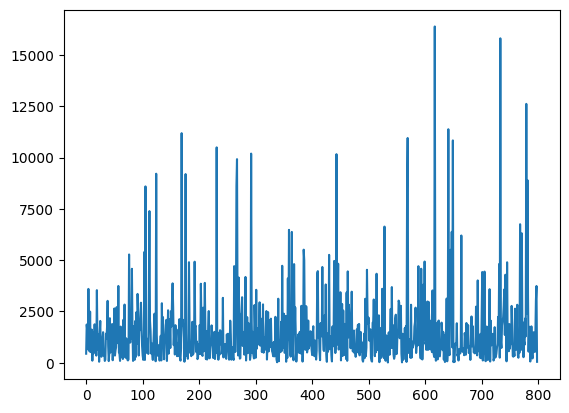

In [7]:
# very basic plot of one feature
df['Order_value'].plot()

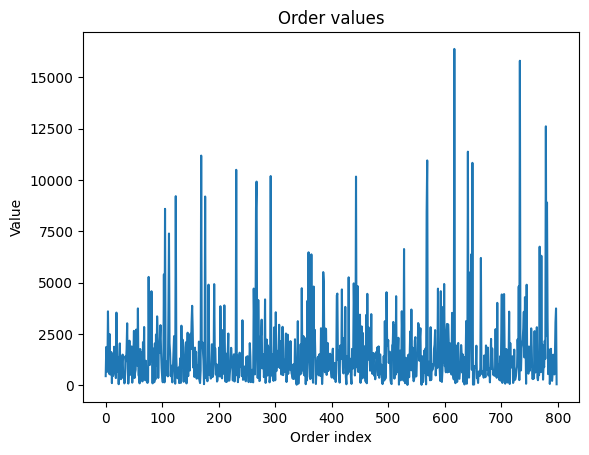

In [18]:
# we can add some meta information onto that plot
df['Order_value'].plot()

# plot title
plt.title("Order values")

# axis labels
plt.xlabel("Order index")
plt.ylabel("Value")

# display the plot
plt.show()

Text(0.5, 1.0, 'Histogram for Order value')

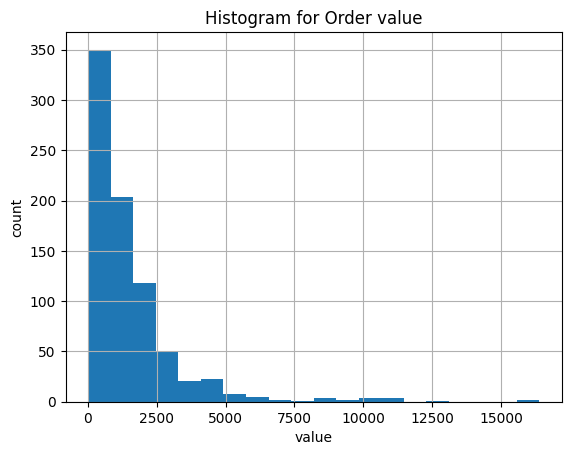

In [25]:
# histogram could be more informative about the distribution of order values
df['Order_value'].hist(bins=20)
plt.ylabel("count")
plt.xlabel("value")
plt.title("Histogram for Order value")

We can achieve similar result with seaborn library.

In [27]:
import seaborn as sns

<Axes: xlabel='Order_value', ylabel='Count'>

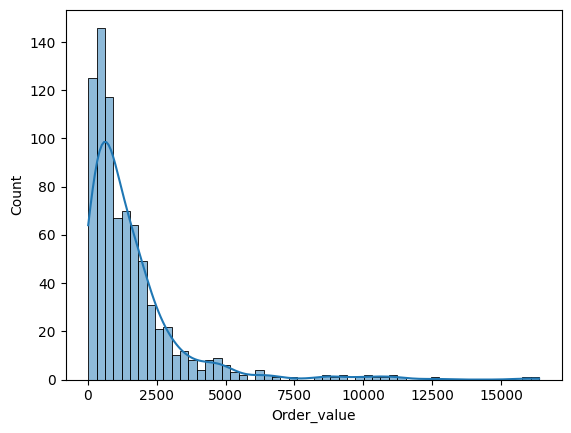

In [67]:
# kde=True will ad also apeobability densityf function curve to the plot
sns.histplot(df['Order_value'], kde=True)

From both plots we see that the data are skewed. Most order values are < 2500 and there are some of them which value is much greater.

Charts are often designed to give us some insight into the data—to group it, show trends, and illustrate proportions. So let’s take a look at a few charts that will be displayed for certain groups of data.

In [33]:
order_value_by_employee = df.groupby(['Employee']).agg({'Order_value': ['sum']})
order_value_by_employee

,Order_value
,sum
Employee,
Callahan,123032.67
Davolio,182500.09
Dudek,75048.04
Fuller,162503.78
King,116962.99
Kowalski,68792.25
Leverling,201196.27
Peacock,225763.68


<Axes: xlabel='Employee'>

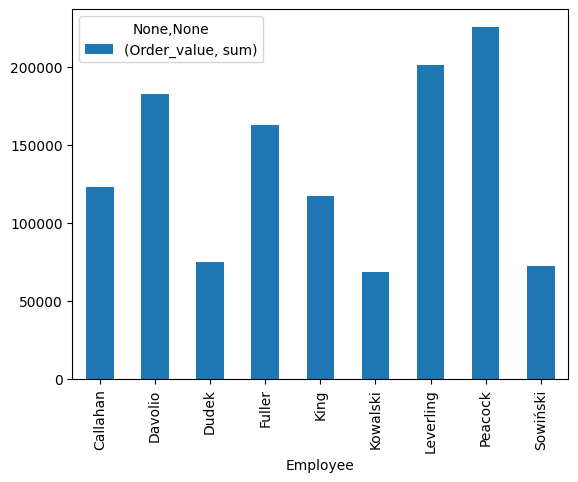

In [34]:
# plot bar from that aggregated data
order_value_by_employee.plot(kind='bar')

> **Documentation for pandas pie plot:** https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.pie.html

array([<Axes: >], dtype=object)

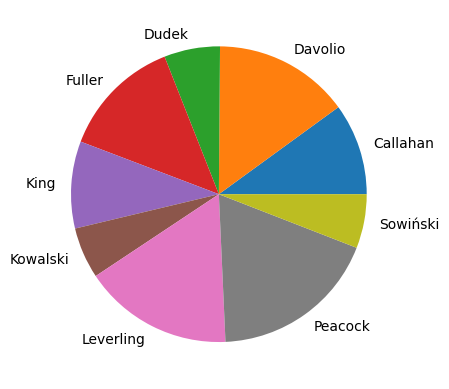

In [39]:
# plot bar from that aggregated data
order_value_by_employee.plot(kind='pie', subplots=True, legend=False)

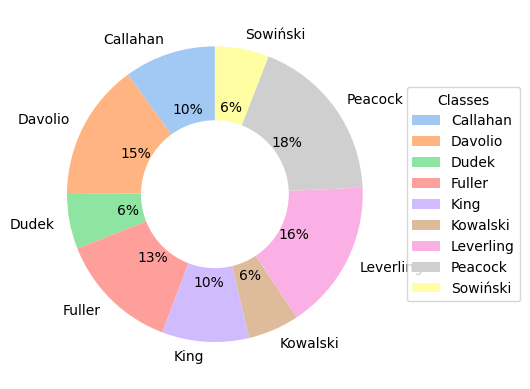

In [42]:
# and a pie plot in seaborn with a little bit of sugar on top of it
colors = sns.color_palette('pastel')

fig, ax = plt.subplots()
data = order_value_by_employee[('Order_value','sum')]
labels = order_value_by_employee.index

# this type of a plot is called a donut plot
wedges, texts, autotexts = ax.pie(
    data,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct='%.0f%%',
    wedgeprops=dict(width=0.5)
)

ax.legend(wedges, labels, title="Classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

## Exercises

**Exercise 1**

In this exercise, we want to display line, bar, and pie charts of order values by:
* a) country,
* b) year the order was placed.

The code snippet that generated these summaries for each employee looks like this:
```python
order_value_by_employee = df.groupby([‘Employee’]).agg({‘Order_value’: [‘sum’]})
```

The `groupby()` function takes a list of columns by which the data will be grouped.  
The `agg()` function is where we define a dictionary whose key is the column name and whose value is a list of functions we want to apply to each group (we can specify multiple functions, e.g., sum, count, min, max, etc.).

For subpoint `a)`, all we need to do is change the column name from `Order_value` to `Country` in both places and give the variable a name other than `order_value_by_employee`, e.g., `order_value_by_country`.

Next, copy the code from the examples for the line, bar, and pie charts, substitute the new variable, and change the label names if any exist.

For point `b)`, there are several ways to approach this.

I’ll show you two.

**_Method 1_**

Change the data type of the `Order_date` column to `datetime` and extract the `year` attribute for it in the `groupby` function.



In [44]:
# converting to datetime if format is correct is very easy
pd.to_datetime(df['Order_date'])

0     2003-07-16
1     2003-07-10
2     2003-07-12
3     2003-07-15
4     2003-07-11
         ...    
794   2005-04-30
795   2005-05-01
796   2005-04-29
797   2005-05-01
798   2005-05-01
Name: Order_date, Length: 799, dtype: datetime64[us]

In [45]:
# but this only returned a pandas Series with transformed data, not replaced the column
# this is good when we want to look at the data before we apply the transformation
# but now we want to do this
df['Order_date'] = pd.to_datetime(df['Order_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Country      799 non-null    str           
 1   Employee     799 non-null    str           
 2   Order_date   799 non-null    datetime64[us]
 3   Order_id     799 non-null    int64         
 4   Order_value  799 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 31.3 KB


In [46]:
# now we can get each component from this column, like year
df['Order_date'].dt.year

0      2003
1      2003
2      2003
3      2003
4      2003
       ... 
794    2005
795    2005
796    2005
797    2005
798    2005
Name: Order_date, Length: 799, dtype: int32

**And now it is very easy to use it in a group function. Try it!**

**_Method 2_**

You can use the example from the previous lesson, where you extracted the first four characters from the `Order_date` cell and used them to group the data.

In [ ]:
# but this column should be restored to its original state (text type)
df['Order_date'] = df['Order_date'].astype(str)

In [55]:
df['Order_date'].str[:4]

0      2003
1      2003
2      2003
3      2003
4      2003
       ... 
794    2005
795    2005
796    2005
797    2005
798    2005
Name: Order_date, Length: 799, dtype: str

           Order_value
                   sum
Order_date            
2003         193316.54
2004         609190.76
2005         425820.10


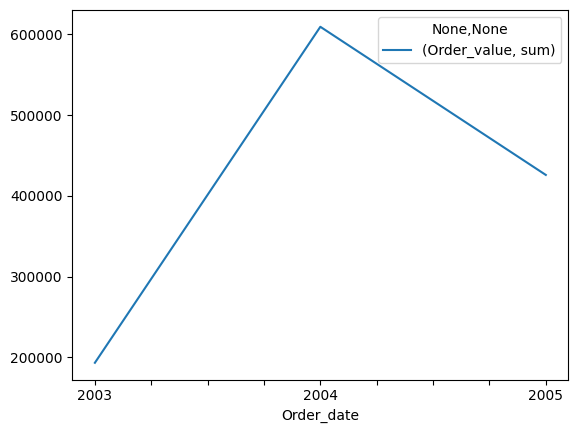

In [61]:
df_sum_by_year_2 = df.groupby(df['Order_date'].str[:4]).agg({'Order_value': ['sum']})
print(df_sum_by_year_2)

# not a very attractive plot
df_sum_by_year_2.plot();

**Now add plots for `a)` and `b)`.**

## 2. Other plotting examples

In [ ]:
# installing (or making sure that this is already installed) bokeh library
!pip install bokeh bokeh_sampledata

In [ ]:
# modified example from https://docs.bokeh.org/en/latest/docs/examples/topics/timeseries/candlestick.html

from bokeh.models import BoxAnnotation
from bokeh.plotting import figure, show
from bokeh.sampledata.stocks import MSFT
from bokeh.io import output_notebook

output_notebook()

df = pd.DataFrame(MSFT)[60:120]
df["date"] = pd.to_datetime(df["date"])

inc = df.close > df.open
dec = df.open > df.close

non_working_days = df[['date']].assign(diff=df['date'].diff()-pd.Timedelta('1D'))
non_working_days = non_working_days[non_working_days['diff']>=pd.Timedelta('1D')]

df['date'] += pd.Timedelta('12h') # move candles to the center of the day

TOOLS = "pan,wheel_zoom,box_zoom,reset,save"

p = figure(x_axis_type="datetime", tools=TOOLS, width=1000, height=400,
           title="MSFT Candlestick", background_fill_color="#efefef")
p.xaxis.major_label_orientation = 0.8 # radians

boxes = [
    BoxAnnotation(fill_color="#bbbbbb", fill_alpha=0.2, left=date-diff, right=date)
    for date, diff in non_working_days.values
]
p.renderers.extend(boxes)

p.segment(df.date, df.high, df.date, df.low, color="black")

p.vbar(df.date[dec], pd.Timedelta('16h'), df.open[dec], df.close[dec], color="#eb3c40")
p.vbar(df.date[inc], pd.Timedelta('16h'), df.open[inc], df.close[inc], fill_color="white",
       line_color="#49a3a3", line_width=2)

show(p)

Loading BokehJS ...

### Exercise

Explore the Eurostat database, choose one dataset and prepare a chart of your choice.

> **Datasets:** https://ec.europa.eu/eurostat/data/database